# ECE 227 Project

## Topic: 1 Network Analysis and Visualization using NetworkX and Gephi

## Group Members
- Jiayi Chen | A17496530 | jic101@ucsd.edu
- Junyi Wu | A17034047 | juw040@ucsd.edu

## 1. Model Preparation

We download the following models:  
1. Collaboration: [GR-QC (General Relativity and Quantum Cosmology) collaboration network](https://snap.stanford.edu/data/ca-GrQc.html). 
2. Enron email network [Enron email network](https://snap.stanford.edu/data/email-Enron.html).  
3. Social circles: Facebook [Social circles: Facebook](https://snap.stanford.edu/data/ego-Facebook.html)

In [23]:

import networkx as nx

# upload the nx file collab enron and fb

G_collab = nx.read_edgelist('models/CA-GrQc.txt')
G_enron = nx.read_edgelist('models/Email-Enron.txt')
G_fb = nx.read_edgelist('models/facebook_combined.txt')

print(f"Facebook: {G_fb.number_of_nodes()} nodes, {G_fb.number_of_edges()} edges")

Facebook: 4039 nodes, 88234 edges


In [24]:
# Degree Centrality (Most connected nodes)
deg_cent_fb = nx.degree_centrality(G_fb)

# Betweenness Centrality (Nodes that act as bridges)
bet_cent_fb = nx.betweenness_centrality(G_fb)

# Eigenvector Centrality (Influence based on neighbor quality)
eig_cent_fb = nx.eigenvector_centrality(G_fb)

In [25]:
def get_top_10_percent(centrality_dict):
    
    num_nodes = len(centrality_dict)
    top_count = int(num_nodes * 0.10)
    sorted_nodes = sorted(centrality_dict, key=centrality_dict.get, reverse=True)
    return set(sorted_nodes[:top_count])

top_deg = get_top_10_percent(deg_cent_fb)
top_bet = get_top_10_percent(bet_cent_fb)

overlap = top_deg.intersection(top_bet)
print(f"Overlap size: {len(overlap)} nodes")

Overlap size: 105 nodes


In [26]:
# Detect communities using the Louvain algorithm
communities_fb = nx.community.louvain_communities(G_fb, seed=123)
communities_enron = nx.community.louvain_communities(G_enron, seed=123)
communities_collab = nx.community.louvain_communities(G_collab, seed=123)

print(f"Facebook communities: {len(communities_fb)}")
print(f"Enron communities: {len(communities_enron)}")
print(f"Collaboration communities: {len(communities_collab)}")

Facebook communities: 16
Enron communities: 1248
Collaboration communities: 391


In [27]:
# Find the largest community in the Collaboration network
largest_comm = max(communities_collab, key=len)

# Get top 5 authors by degree within this community
subgraph = G_collab.subgraph(largest_comm)
top_5_authors = sorted(subgraph.degree, key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Authors in the Largest Collaboration Community:")
for author, degree in top_5_authors:
    print(f"Node ID: {author} | Internal Degree: {degree}")

Top 5 Authors in the Largest Collaboration Community:
Node ID: 13801 | Internal Degree: 35
Node ID: 5901 | Internal Degree: 23
Node ID: 13142 | Internal Degree: 21
Node ID: 23134 | Internal Degree: 17
Node ID: 5695 | Internal Degree: 17


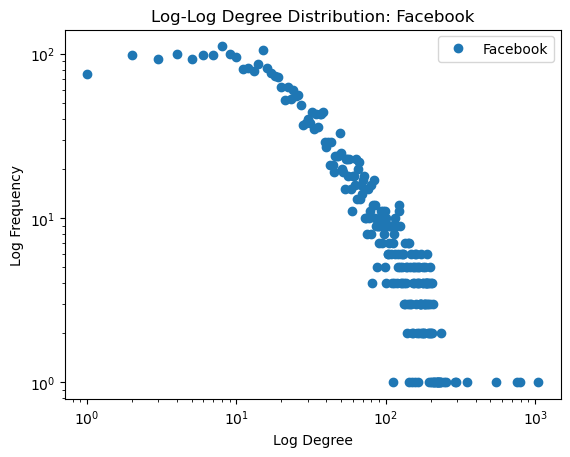

In [28]:
import matplotlib.pyplot as plt
import collections

def plot_degree_dist(G, name):
    degrees = [d for n, d in G.degree()]
    count = collections.Counter(degrees)
    deg, cnt = zip(*count.items())
    
    plt.loglog(deg, cnt, 'o', label=name)
    plt.xlabel('Log Degree')
    plt.ylabel('Log Frequency')
    plt.title(f'Log-Log Degree Distribution: {name}')
    plt.legend()
    plt.show()

plot_degree_dist(G_fb, "Facebook")

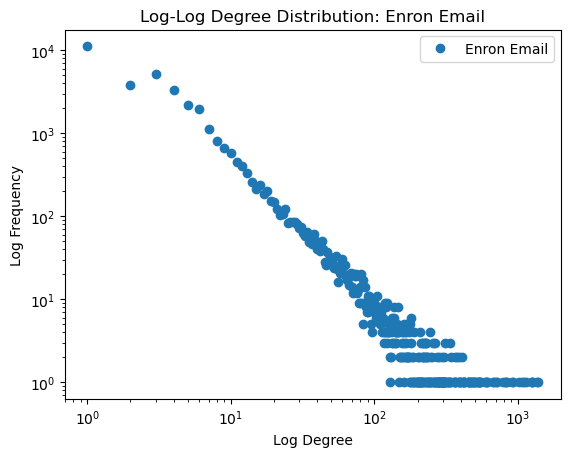

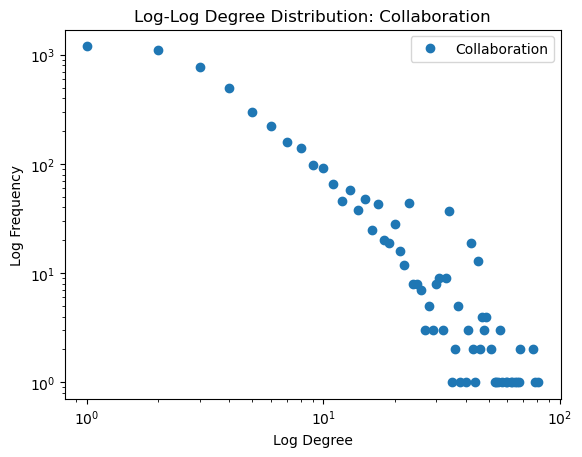

In [29]:
# Run for the other two networks
plot_degree_dist(G_enron, "Enron Email")
plot_degree_dist(G_collab, "Collaboration")

In [ ]:
# Perform community detection
communities_collab = nx.community.louvain_communities(G_collab, seed=123)

# Find the largest community in the Collaboration graph
largest_comm = max(communities_collab, key=len)

# Get top 5 authors by degree within this specific community
subgraph = G_collab.subgraph(largest_comm)
top_5_authors = sorted(subgraph.degree, key=lambda x: x[1], reverse=True)[:5]

print(f"Top 5 authors in the largest community:")
for author, degree in top_5_authors:
    print(f"Author ID: {author} | Connections: {degree}")

Top 5 authors in the largest Collaboration community:
Author ID: 13801 | Connections: 35
Author ID: 5901 | Connections: 23
Author ID: 13142 | Connections: 21
Author ID: 23134 | Connections: 17
Author ID: 5695 | Connections: 17
